<a href="https://colab.research.google.com/github/srivastavalove736/CODSOFT_TASKSNO/blob/main/_TASK_3_DATA_VISUALIZATION_DASHBOARD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_857/2924769465.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_totals.index, y=category_totals.values, ax=axes[0, 0], palette='Blues_d')


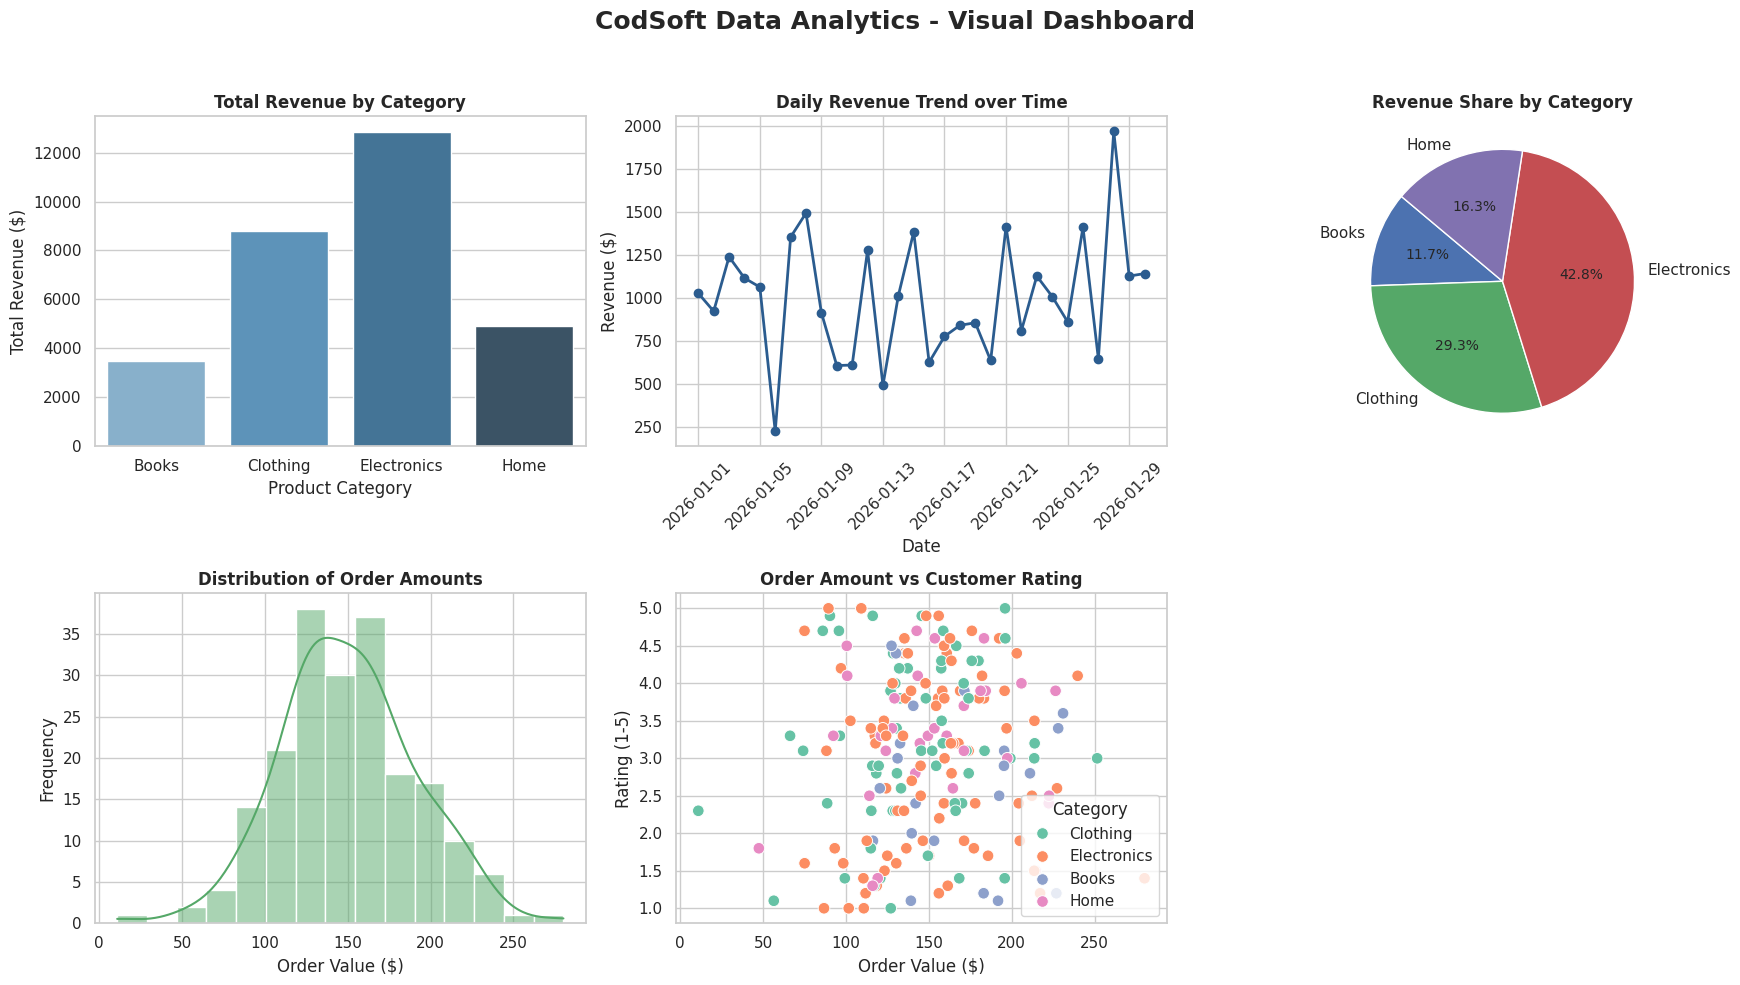


Dashboard image generated and saved successfully as 'visualization_dashboard.png'


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

np.random.seed(42)
dates = pd.date_range(start="2026-01-01", periods=30, freq="D")
categories = ['Electronics', 'Clothing', 'Home', 'Books']

data = {
    'Date': np.random.choice(dates, size=200),
    'Category': np.random.choice(categories, size=200, p=[0.4, 0.3, 0.2, 0.1]),
    'Sales_Amount': np.random.normal(loc=150, scale=40, size=200).round(2),
    'Customer_Rating': np.random.uniform(1.0, 5.0, size=200).round(1),
    'Discount_Percent': np.random.choice([0, 5, 10, 15, 20], size=200)
}

df = pd.DataFrame(data)

daily_sales = df.groupby('Date')['Sales_Amount'].sum().reset_index()
category_totals = df.groupby('Category')['Sales_Amount'].sum()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CodSoft Data Analytics - Visual Dashboard', fontsize=18, fontweight='bold', y=0.98)

sns.barplot(x=category_totals.index, y=category_totals.values, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Total Revenue by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Product Category')
axes[0, 0].set_ylabel('Total Revenue ($)')

axes[0, 1].plot(daily_sales['Date'], daily_sales['Sales_Amount'], color='#2b5c8f', marker='o', linewidth=2)
axes[0, 1].set_title('Daily Revenue Trend over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[0, 2].pie(category_totals.values, labels=category_totals.index, autopct='%1.1f%%',
               colors=['#4c72b0', '#55a868', '#c44e52', '#8172b0'], startangle=140)
axes[0, 2].set_title('Revenue Share by Category', fontsize=12, fontweight='bold')

sns.histplot(df['Sales_Amount'], kde=True, ax=axes[1, 0], color='#55a868', bins=15)
axes[1, 0].set_title('Distribution of Order Amounts', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Order Value ($)')
axes[1, 0].set_ylabel('Frequency')

sns.scatterplot(x='Sales_Amount', y='Customer_Rating', hue='Category', data=df, ax=axes[1, 1], palette='Set2', s=70)
axes[1, 1].set_title('Order Amount vs Customer Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Order Value ($)')
axes[1, 1].set_ylabel('Rating (1-5)')
axes[1, 1].legend(title='Category', loc='lower right')

fig.delaxes(axes[1, 2])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('visualization_dashboard.png', dpi=300)
plt.show()

print("\nDashboard image generated and saved successfully as 'visualization_dashboard.png'")